# Team Members
  - Mohamed ahmed mohamed (Abdallah)
  - Milad Ashraf Khalaf Mekhail

# 1 - Reading and inspecting the data

## 1.1 - Initial inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("UsedCarsSA_Unclean_EN.csv")
data.head()

,Link,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
0,https://syarah.com/%D9%83%D8%B1%D8%A7%D9%8A%D8...,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,Used,103000,Riyadh,114000,False
1,https://syarah.com/%D9%86%D9%8A%D8%B3%D8%A7%D9...,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,Used,5448,Riyadh,Negotiable,True
2,https://syarah.com/online/%D9%86%D9%8A%D8%B3%D...,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,Used,72418,Riyadh,27500,False
3,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,Used,114154,Riyadh,43000,False
4,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,Used,41912,Riyadh,59500,False


In [ ]:
# data.drop("Link",inplace=True,axis=1)
# data.head()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Link         8248 non-null   object 
 1   Make         8248 non-null   object 
 2   Type         8248 non-null   object 
 3   Year         8248 non-null   int64  
 4   Origin       8153 non-null   object 
 5   Color        8248 non-null   object 
 6   Options      8139 non-null   object 
 7   Engine_Size  5982 non-null   float64
 8   Fuel_Type    8248 non-null   object 
 9   Gear_Type    8174 non-null   object 
 10  Condition    8248 non-null   object 
 11  Mileage      8248 non-null   int64  
 12  Region       8248 non-null   object 
 13  Price        8248 non-null   object 
 14  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(11)
memory usage: 910.3+ KB


In [ ]:
data.shape

(8248, 15)

In [ ]:
data.describe(exclude='number')

,Link,Make,Type,Origin,Color,Options,Fuel_Type,Gear_Type,Condition,Region,Price,Negotiable
count,8248,8248,8248,8153,8248,8139,8248,8174,8248,8248,8248,8248
unique,8228,65,435,3,15,3,3,2,1,27,549,2
top,https://syarah.com/%D8%B4%D9%81%D8%B1%D9%88%D9...,Toyota,Land Cruiser,Saudi,White,Full,Gas,Automatic,Used,Riyadh,Negotiable,False
freq,2,2074,374,6084,3574,3235,8051,7069,8248,3312,2596,5652


In [ ]:
data.isnull().sum()

,0
Link,0
Make,0
Type,0
Year,0
Origin,95
Color,0
Options,109
Engine_Size,2266
Fuel_Type,0
Gear_Type,74


In [ ]:
data["Price"].sample(5)

,Price
8179,Negotiable
6473,Negotiable
3327,15000
1693,61500
2292,87000


## 1.2 - Dublicate Values

In [ ]:
# with link
data.duplicated().sum()

np.int64(20)

In [ ]:
# Link Excluded
data.duplicated(subset=data.columns.drop("Link")).sum()

np.int64(69)

In [ ]:
# 1. Find which rows are duplicated (mark ALL copies)
dupes = data[data.duplicated(keep=False)]

# 2. Sort them so duplicate rows sit next to each other
dupes = dupes.sort_values(by=list(data.columns))
print("Number of duplicate rows:", len(dupes))
display(dupes)

Number of duplicate rows: 40


,Link,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
5019,https://syarah.com/%D8%A8%D9%8A_%D8%A7%D9%85_%...,BMW,X,2015,Saudi,White,Full,2.0,Gas,Automatic,Used,92000,Jeddah,72000,False
5020,https://syarah.com/%D8%A8%D9%8A_%D8%A7%D9%85_%...,BMW,X,2015,Saudi,White,Full,2.0,Gas,Automatic,Used,92000,Jeddah,72000,False
6530,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Prado,2019,Gulf Arabic,White,Full,4.0,Gas,Automatic,Used,19054,Riyadh,162500,False
6531,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Prado,2019,Gulf Arabic,White,Full,4.0,Gas,Automatic,Used,19054,Riyadh,162500,False
3374,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Prado,2015,Saudi,White,Semi Full,2.7,Gas,Automatic,Used,97000,Jeddah,Negotiable,True
3379,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Prado,2015,Saudi,White,Semi Full,2.7,Gas,Automatic,Used,97000,Jeddah,Negotiable,True
686,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Camry,2017,Saudi,Another Color,Full,2.5,Gas,Automatic,Used,61000,Riyadh,77000,False
691,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Camry,2017,Saudi,Another Color,Full,2.5,Gas,Automatic,Used,61000,Riyadh,77000,False
319,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Camry,2016,Gulf Arabic,White,Standard,2.5,Gas,Automatic,Used,81000,Riyadh,62000,False
331,https://syarah.com/%D8%AA%D9%88%D9%8A%D9%88%D8...,Toyota,Camry,2016,Gulf Arabic,White,Standard,2.5,Gas,Automatic,Used,81000,Riyadh,62000,False


## 1.3 - Unique Values

In [ ]:
# Displays count, unique, top, and freq for categorical columns
display(data.describe(exclude='number'))

# Displays the exact number of unique values for every single column
print("Number of unique values per column:")
print(data.nunique())

,Link,Make,Type,Origin,Color,Options,Fuel_Type,Gear_Type,Condition,Region,Price,Negotiable
count,8248,8248,8248,8153,8248,8139,8248,8174,8248,8248,8248,8248
unique,8228,65,435,3,15,3,3,2,1,27,549,2
top,https://syarah.com/%D8%B4%D9%81%D8%B1%D9%88%D9...,Toyota,Land Cruiser,Saudi,White,Full,Gas,Automatic,Used,Riyadh,Negotiable,False
freq,2,2074,374,6084,3574,3235,8051,7069,8248,3312,2596,5652


Number of unique values per column:
Link           8228
Make             65
Type            435
Year             55
Origin            3
Color            15
Options           3
Engine_Size      75
Fuel_Type         3
Gear_Type         2
Condition         1
Mileage        2196
Region           27
Price           549
Negotiable        2
dtype: int64


## 1.4 - Initial correlation
  - This is used to see how other variables **affect** our **Target**

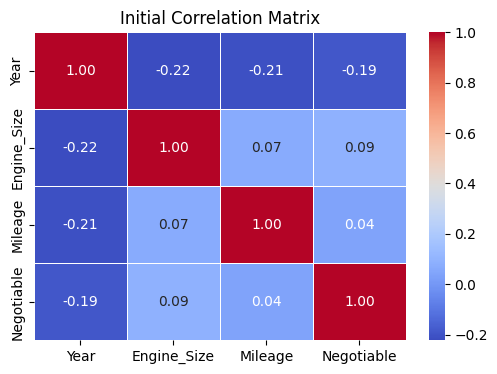

In [ ]:
# Correlation
# Calculate the correlation matrix for numerical columns only
corr_matrix = data.corr(numeric_only=True)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Initial Correlation Matrix')
plt.show()

# (Phase 1 Summary)

**Dataset Overview**
* **Shape:** 8,248 rows × 15 columns.
* **Usable Numeric Columns:** Currently only 2 fully numeric (`Year`, `Mileage`) and 1 partial (`Engine_Size`).

**Data Quality Issues Identified**
1. **Target Variable Error:** The `Price` column is currently stored as an `object` (text) rather than a numeric format, which prevents it from appearing in our initial correlation matrix.
2. **Missing Data:** `Engine_Size` is missing a significant portion of its data (27.5% / 2,266 rows). Minor missing values exist in `Options`, `Origin`, and `Gear_Type` (<2%).
3. **Zero Variance:** The `Condition` column contains only a single unique value across all 8,248 rows, providing no predictive value.
4. **Duplicates:** There are 20 exact full-row duplicates, and 69 semantic duplicates if the unique URL `Link` is ignored.

**Initial Correlation Insights**
* Early numeric correlations (`Year`, `Engine_Size`, `Mileage`, `Negotiable`) are weak overall (|r| ≤ 0.22).
* Expected trends are visible: Newer cars (`Year`) negatively correlate with `Mileage` (-0.21) and the likelihood to be `Negotiable` (-0.19).

**Next Steps (Phase 2: Cleaning & Transformation)**
* Drop the useless `Condition` and `Link` columns.
* Convert `Price` to a numeric float so it can be evaluated.
* Remove the 20 exact duplicate rows.
* Standardize messy text fields (Make/Type typos) and formulate an imputation strategy for `Engine_Size`.

# 2 - Cleaning and Transformation

## 2.1 Unifing names

### 2.1.1 Brand Names

In [ ]:
# Brand name unification mapping for the 'Make' column
# Key   = raw / messy value found in the data
# Value = clean, standardized brand name
# These are based on what Gemini gave us

BRAND_MAPPING = {

    # ---- ⚠️ 1. Typos & Partial Names ----
    'Skoda':   'Skoda',
    'skoda':   'Skoda',
    'Škoda':   'Skoda',
    'Å koda':  'Skoda',
    'Ashok':         'Ashok Leyland',  # partial → full name
    'Ashok Leyland': 'Ashok Leyland',
    'Mercedes':      'Mercedes-Benz',  # partial → official name
    'Mercedes-Benz': 'Mercedes-Benz',
    'Mercedes Benz': 'Mercedes-Benz',
    'SsangYong':     'SsangYong',      # keep (or map to 'KG Mobility')
    'Ssangyong':     'SsangYong',
    'KG Mobility':   'SsangYong',      # new name → unify to classic
    'KGM':           'SsangYong',

    # ---- ❌ 2. Not Real Car Brands (categories / placeholders) ----
    'Classic':       'Unknown',        # category, not a brand
    'Other':         'Unknown',        # placeholder
    '(blank)':       'Unknown',        # empty field
    '':              'Unknown',
    'NaN':           'Unknown',
    'Unknown':       'Unknown',

    # ---- ℹ️ 3. Lesser-Known but Valid (Chinese + others) ----
    'FAW':           'FAW',
    'Foton':         'Foton',
    'GAC':           'GAC',
    'Geely':         'Geely',
    'Great Wall':    'Great Wall',
    'HAVAL':         'HAVAL',
    'Haval':         'HAVAL',
    'JAC':           'JAC',
    'Lifan':         'Lifan',
    'Changan':       'Changan',
    'Chery':         'Chery',
    'BYD':           'BYD',
    'MAN':           'MAN',
    'Victory Auto':  'Victory Auto',
    'Zhengzhou':     'Zhengzhou Nissan',
    'Zhengzhou Nissan': 'Zhengzhou Nissan',

    # ---- ✅ 4. Already Valid — normalize casing/spacing ----
    'Aston Martin':  'Aston Martin',
    'Audi':          'Audi',
    'Bentley':       'Bentley',
    'BMW':           'BMW',
    'Buick':         'Buick',
    'Cadillac':      'Cadillac',
    'Chevrolet':     'Chevrolet',
    'Chrysler':      'Chrysler',
    'Daihatsu':      'Daihatsu',
    'Dodge':         'Dodge',
    'Ferrari':       'Ferrari',
    'Fiat':          'Fiat',
    'Ford':          'Ford',
    'Genesis':       'Genesis',
    'GMC':           'GMC',
    'Honda':         'Honda',
    'Hummer':        'Hummer',
    'Hyundai':       'Hyundai',
    'INFINITI':      'Infiniti',       # unify casing
    'Infiniti':      'Infiniti',
    'Isuzu':         'Isuzu',
    'Iveco':         'Iveco',
    'Jaguar':        'Jaguar',
    'Jeep':          'Jeep',
    'Kia':           'Kia',
    'Land Rover':    'Land Rover',
    'LandRover':     'Land Rover',
    'Lexus':         'Lexus',
    'Lincoln':       'Lincoln',
    'Maserati':      'Maserati',
    'Mazda':         'Mazda',
    'Mercury':       'Mercury',
    'MG':            'MG',
    'MINI':          'MINI',
    'Mini':          'MINI',
    'Mitsubishi':    'Mitsubishi',
    'Nissan':        'Nissan',
    'Peugeot':       'Peugeot',
    'Pontiac':       'Pontiac',
    'Porsche':       'Porsche',
    'Renault':       'Renault',
    'Rolls-Royce':   'Rolls-Royce',
    'Rolls Royce':   'Rolls-Royce',
    'Subaru':        'Subaru',
    'Suzuki':        'Suzuki',
    'Tata':          'Tata',
    'Toyota':        'Toyota',
    'Volkswagen':    'Volkswagen',
    'Volvo':         'Volvo',
}

In [ ]:
# Build a case-insensitive lookup
BRAND_LOOKUP = {k.strip().lower(): v for k, v in BRAND_MAPPING.items()}

data['Make'] = (
    data['Make']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(BRAND_LOOKUP)
    .fillna(data['Make'])   # keep anything not in the dictionary as-is
)

In [ ]:
raw = set(data['Make'].astype(str).str.strip().str.lower().unique())
missing = sorted(raw - set(BRAND_LOOKUP.keys()))
print(f"{len(missing)} unmapped values:")
for m in missing:
    print(" -", repr(m))

0 unmapped values:


In [ ]:
print("Unique brands after cleaning:", data['Make'].nunique())
print(data['Make'].value_counts().head(15))

Unique brands after cleaning: 64
Make
Toyota           2074
Hyundai           952
Ford              779
Chevrolet         672
Nissan            552
GMC               411
Kia               359
Mercedes-Benz     349
Lexus             345
Mazda             190
Honda             188
BMW               134
Mitsubishi        131
Dodge             123
Land Rover        101
Name: count, dtype: int64


### 2.1.2 - Type Names

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# MODEL MAPPING TABLE
# columns: messy_type | correct_type | correct_make (None = keep)
# ------------------------------------------------------------
MODEL_FIXES = pd.DataFrame([
    # ---- ⚠️ 1. Autocorrect Typos ----
    ('Toyota Furniture',           'Fortuner',         None),
    ('Maserati Gamble',            'Ghibli',           None),
    ('Kia Cores',                  'Quoris',           None),
    ('Chevrolet Abeka',            'Epica',            None),
    ('Toyota Ciocca',              'Sequoia',          None),
    ('Ford Vego',                  'Figo',             None),
    ('MINI Copper',                'Cooper',           None),
    ('Mitsubishi Osa Bus',         'Rosa Bus',         None),
    ('Nissan Sylvian Bus',         'Civilian Bus',     None),

    # ---- 🚫 2. Wrong Brand → also fix Make ----
    ('Lincoln Continental GT',     'Continental GT',   'Bentley'),
    ('Nissan Land Cruiser Pickup', 'Land Cruiser Pickup', 'Toyota'),
    ("Suzuki D'max",               'D-MAX',            'Isuzu'),
    ('Suzuki Dmax',                'D-MAX',            'Isuzu'),
    ('Isuzu Dyna',                 'Dyna',             'Toyota'),
    ('JAC Dyna',                   'Dyna',             'Toyota'),
    ('Tata Dyna',                  'Dyna',             'Toyota'),
    ('Mercury Montero1',           'Montego',          'Mercury'),
    ('Mercury Montero2',           'Monterey',         'Mercury'),
    ('Ford Marquis',               'Grand Marquis',    'Mercury'),

    # ---- ✍️ 3. Formatting & Spelling ----
    ('FAW Ù ACTIS V80',            'Actis V80',        None),
    ('FAW Ù ACTIS V80',            'Actis V80',        None),
    ('Hyundai Senta fe',           'Santa Fe',         None),
    ('Hyundai Santa fe',           'Santa Fe',         None),
    ('SsangYong Koranado',         'Korando',          None),
    ('Renault Capture',            'Captur',           None),
    ('Foton Suvana',               'Sauvana',          None),
    ('Kia Carenz',                 'Carens',           None),
    ('Chevrolet Kaptiva',          'Captiva',          None),
    ('Škoda',                      'Fabia',            None),  # placeholder if it appears as Type

    # ---- 🏷️ 4. Trims / categories → clean or Unknown ----
    ('GMC Behbehani',              'Sierra',           'GMC'),  # or Yukon
    ('Genesis Platinum',           'G80',              'Genesis'),
    ('Genesis Prestige',           'G80',              'Genesis'),
    ('Genesis Royal',              'G80',              'Genesis'),
    ('Mercedes POS24',             'Unknown',          'Mercedes-Benz'),
    ('Mercedes ALB',               'GLB',              'Mercedes-Benz'),
    ('Classic',                    'Unknown',          None),
    ('Other',                      'Unknown',          None),
    ('(blank)',                    'Unknown',          None),
    ('Bus County', 'County Bus', 'Hyundai'),
    ('Bus Urvan', 'Urvan', 'Nissan'),
    ('Big Truck', 'Unknown', None),
    ('Cayenne S', 'Cayenne', None),
    ('Cayenne Turbo', 'Cayenne', None),
    ('Cayenne Turbo GTS', 'Cayenne', None),
    ('Cayenne Turbo S', 'Cayenne', None),
    ('Coupe S', 'Coupe', None),
    ('Capture', 'Captur', 'Renault'),
    ('Behbehani', 'Sierra', 'GMC'),
    ('Cadillac', 'Unknown', None),
], columns=['messy_type', 'correct_type', 'correct_make'])

In [ ]:
# ------------------------------------------------------------
# Step 1: Normalize whitespace + fix mojibake in BOTH columns
# ------------------------------------------------------------
for col in ['Make', 'Type']:
    data[col] = (data[col].astype(str)
                 .str.strip()
                 .str.replace(r'\s+', ' ', regex=True)
                 .str.replace('Ã…', 'Å', regex=False)
                 .str.replace('Ã¥', 'å', regex=False)
                 .str.replace('Ù', '', regex=False)    # strip stray Arabic char
                 .str.strip())

# ------------------------------------------------------------
# Step 2: Build lookup dicts (case-insensitive)
# ------------------------------------------------------------
TYPE_LOOKUP  = {row.messy_type.strip().lower(): row.correct_type
                for row in MODEL_FIXES.itertuples()}

MAKE_LOOKUP_FROM_TYPE = {row.messy_type.strip().lower(): row.correct_make
                         for row in MODEL_FIXES.itertuples()
                         if row.correct_make is not None}

# ------------------------------------------------------------
# Step 3: Apply model fixes (only where a mapping exists)
# ------------------------------------------------------------
lower_type = data['Type'].str.lower()
data['Type'] = lower_type.map(TYPE_LOOKUP).fillna(data['Type'])

# ------------------------------------------------------------
# Step 4: Fix the Make for rows where the brand was wrong
# ------------------------------------------------------------
mask = lower_type.isin(MAKE_LOOKUP_FROM_TYPE.keys())
data.loc[mask, 'Make'] = lower_type[mask].map(MAKE_LOOKUP_FROM_TYPE)

# ------------------------------------------------------------
# Step 5: Verify
# ------------------------------------------------------------
print("Unique types:", data['Type'].nunique())
print("\nSample fixes applied:")
print(data[data['Type'].isin(['Fortuner', 'D-MAX', 'Land Cruiser Pickup',
                               'Santa Fe', 'Captiva', 'Korando'])][['Make', 'Type']].head(20))

Unique types: 427

Sample fixes applied:
        Make                 Type
289   Toyota  Land Cruiser Pickup
372   Nissan  Land Cruiser Pickup
459   Toyota  Land Cruiser Pickup
507   Nissan  Land Cruiser Pickup
566   Toyota  Land Cruiser Pickup
684   Toyota  Land Cruiser Pickup
788   Toyota  Land Cruiser Pickup
925   Toyota  Land Cruiser Pickup
1037   Isuzu                D-MAX
1085  Toyota  Land Cruiser Pickup
1322   Isuzu                D-MAX
1377   Isuzu                D-MAX
1434   Isuzu                D-MAX
1493  Toyota  Land Cruiser Pickup
1627  Toyota  Land Cruiser Pickup
1687  Toyota  Land Cruiser Pickup
1695  Toyota  Land Cruiser Pickup
1736  Toyota  Land Cruiser Pickup
1767  Toyota  Land Cruiser Pickup
1791  Toyota  Land Cruiser Pickup


In [ ]:
# Check which Types are still messy AFTER fixes were applied
applied = set(m.lower() for m in MODEL_FIXES['messy_type'])
still_messy = sorted(set(data['Type'].str.lower()) & applied)

print(f"Rows still containing a known-bad Type: {len(still_messy)}")
for v in still_messy:
    print(" -", repr(v))

Rows still containing a known-bad Type: 0


## 2.2 -  Transforming data Types

In [ ]:
# Fix Price (object → numeric); text values become NaN
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

# Convert to categorical
categorical_cols = [
    'Make', 'Type', 'Origin', 'Color', 'Options',
    'Fuel_Type', 'Gear_Type', 'Condition', 'Region'
]
for col in categorical_cols:
    data[col] = data[col].astype('category')

# Verify
print(data.dtypes)

Link             object
Make           category
Type           category
Year              int64
Origin         category
Color          category
Options        category
Engine_Size     float64
Fuel_Type      category
Gear_Type      category
Condition      category
Mileage           int64
Region         category
Price           float64
Negotiable         bool
dtype: object


## 2.3 - Dropping Columns

After cleaning, we now inspect which columns actually contribute to predicting **Price**.
We use two checks:
1. **Correlation with Price** — weak or zero correlation means no predictive power.
2. **Constant columns** — columns with only one unique value carry no information.


In [ ]:
# Check correlation of Price with numeric-encoded candidates
check_cols = ['Origin', 'Region', 'Negotiable']
for col in check_cols:
    data[col + '_code'] = data[col].astype('category').cat.codes
    corr = data['Price'].corr(data[col + '_code'])
    print(f"{col:12} → correlation with Price: {corr: .4f}")

# Drop the temp code columns
data.drop(columns=[c + '_code' for c in check_cols], inplace=True)

Origin       → correlation with Price: -0.1635
Region       → correlation with Price:  0.0070
Negotiable   → correlation with Price:  nan


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
data.drop(columns=['Link', 'Origin', 'Region', 'Negotiable', 'Condition'], inplace=True)

Based on these checks, we drop columns that do not affect the price model:
- **Link** — URLs carry no predictive weight.
- **Origin**, **Region** — correlation with Price is negligible (-0.16 and 0.007).
- **Negotiable** — constant column (zero variance).
- **Condition** — only 1 unique value, so it provides no information.

### 2.3.1 ReInspecting the data

In [ ]:
data.head()

,Make,Type,Year,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Price
0,Chrysler,C300,2018,Black,Full,5.7,Gas,Automatic,103000,114000.0
1,Nissan,Patrol,2016,White,Full,4.8,Gas,Automatic,5448,NaN
2,Nissan,Sunny,2019,Silver,Standard,1.5,Gas,Automatic,72418,27500.0
3,Hyundai,Elantra,2019,Grey,Standard,1.6,Gas,Automatic,114154,43000.0
4,Hyundai,Elantra,2019,Silver,Semi Full,2.0,Gas,Automatic,41912,59500.0


In [ ]:
data.shape

(8248, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Make         8248 non-null   category
 1   Type         8248 non-null   category
 2   Year         8248 non-null   int64   
 3   Color        8248 non-null   category
 4   Options      8139 non-null   category
 5   Engine_Size  5982 non-null   float64 
 6   Fuel_Type    8248 non-null   category
 7   Gear_Type    8174 non-null   category
 8   Mileage      8248 non-null   int64   
 9   Price        5652 non-null   float64 
dtypes: category(6), float64(2), int64(2)
memory usage: 337.4 KB


In [ ]:
data.describe()

,Year,Engine_Size,Mileage,Price
count,8248.000000,5982.000000,8.248000e+03,5.652000e+03
mean,2014.014064,3.175794,1.494128e+05,7.853659e+04
std,5.935349,1.567480,3.455258e+05,7.607374e+04
min,1936.000000,1.000000,1.000000e+02,0.000000e+00
25%,2012.000000,2.000000,3.700000e+04,3.500000e+04
50%,2016.000000,2.700000,1.016575e+05,5.800000e+04
75%,2018.000000,4.000000,1.955520e+05,9.500000e+04
max,2022.000000,9.000000,2.000000e+07,1.150000e+06


In [ ]:
data.isnull().sum()

,0
Make,0
Type,0
Year,0
Color,0
Options,109
Engine_Size,2266
Fuel_Type,0
Gear_Type,74
Mileage,0
Price,2596


# (Phase 2 Summary)

**1. Text Standardization**
* **Brand & Model Unification:** Successfully applied case-insensitive mapping dictionaries to fix autocorrect typos, mojibake (encoding errors), and stray characters in the `Make` and `Type` columns.
* **Misplaced Brands:** Correctly reassigned models that were categorized under the wrong brand (e.g., shifting the "Continental GT" to Bentley and "Dyna" to Toyota).

**2. Data Type Optimization & Memory Reduction**
* **Target Variable:** Forced the `Price` column to numeric (`float64`). Text values like "Negotiable" were naturally coerced into `NaN`.
* **Categorical Types:** Converted all remaining text features into pandas `category` dtypes.
* **Result:** Memory usage dropped drastically by ~63% (from 910+ KB down to 337.4 KB).

**3. Feature Selection (Dropping Columns)**
Pruned the dataset to 10 highly relevant columns by dropping:
* `Link`: Irrelevant URL strings.
* `Condition`: Zero variance (only contained "Used").
* `Origin` & `Region`: Negligible linear correlation with Price (-0.16 and 0.007, respectively).
* `Negotiable`: Highly redundant and returned a `NaN` correlation.

**Current Dataset State**
* **Shape:** 8,248 rows × 10 columns
* **Target (`Price`):** 5,652 valid numeric prices; 2,596 missing values (formerly the "Negotiable" cars).
* **Missing Features:** `Engine_Size` (2,266 missing), `Options` (109 missing), `Gear_Type` (74 missing).

**Next Steps (Phase 3: Outliers & Imputation)**
1. Drop the duplicate rows identified in Phase 1.
2. Handle the 2,596 rows missing a `Price` (drop them or separate them).
3. Filter out extreme `Mileage` and `Engine_Size` outliers.
4. Impute missing values for `Engine_Size` and `Gear_Type`.

# 3 - Outliers

In [ ]:
data.isnull().sum()

,0
Make,0
Type,0
Year,0
Color,0
Options,109
Engine_Size,2266
Fuel_Type,0
Gear_Type,74
Mileage,0
Price,2596


## 3.1 - droping duplicates

In [ ]:
data.shape

(8248, 10)

In [ ]:
# with link
print("Duplicates before drop: ",data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("Duplicates after drop: ",data.duplicated().sum())

Duplicates before drop:  73
Duplicates after drop:  0


In [ ]:
data.shape

(8175, 10)

## 3.2 - Price column

In [ ]:
data.shape

(8175, 10)

In [ ]:
data["Price"].sample(3) # the given NaN are just Negotiable

,Price
4709,105000.0
6812,42500.0
4833,2069.0


In [ ]:
# Droping Negotiable as they are useless in our prediction problem
data.dropna(subset=['Price'], inplace=True)
data.shape

(5590, 10)

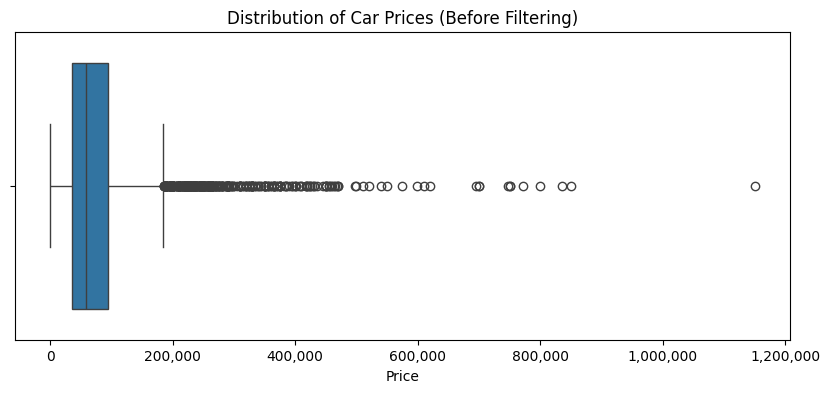

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 4))
sns.boxplot(x=data['Price'])
plt.title('Distribution of Car Prices (Before Filtering)')

# Force plain numbers and add commas for readability (e.g., 1,000,000)
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [ ]:
# Define the price cutoffs for our buckets
bins = [0, 3000, 20000, 50000, 100000, 200000, 500000, float('inf')]

# Create readable labels for each bucket
labels = [
    '0 - 3,000 (Anomalies)',
    '3,001 - 20,000',
    '20,001 - 50,000',
    '50,001 - 100,000',
    '100,001 - 200,000',
    '200,001 - 500,000',
    '500,000+'
]

# Use pd.cut to group the Price column into these bins
price_buckets = pd.cut(data['Price'], bins=bins, labels=labels, include_lowest=True)

# Count the occurrences, keep the bin order, and convert to a DataFrame table
bucket_table = price_buckets.value_counts(sort=False).reset_index()
bucket_table.columns = ['Price Range (SAR)', 'Number of Cars']

# Display the grouped table
display(bucket_table)

print("-" * 50)

# Show exactly which cars fall into the 0 - 3,000 anomaly bucket
anomalies = data[data['Price'] <= 3000]
print(f"Details of the {len(anomalies)} cars priced 3,000 SAR or below:")
display(anomalies[['Make', 'Type', 'Year', 'Price']].sort_values('Price'))

,Price Range (SAR),Number of Cars
0,"0 - 3,000 (Anomalies)",89
1,"3,001 - 20,000",461
2,"20,001 - 50,000",1875
3,"50,001 - 100,000",1919
4,"100,001 - 200,000",932
5,"200,001 - 500,000",295
6,"500,000+",19


--------------------------------------------------
Details of the 89 cars priced 3,000 SAR or below:


,Make,Type,Year,Price
3814,Toyota,Furniture,2012,0.0
8236,GMC,Yukon,2019,1.0
7181,Genesis,G80,2018,500.0
7829,Toyota,Yaris,2018,850.0
2252,Mitsubishi,Attrage,2019,877.0
...,...,...,...,...
7597,Hyundai,Azera,2021,2690.0
6959,Dodge,Charger,2018,2700.0
7063,Dodge,Durango,2019,2820.0
1742,Ford,Victoria,2001,3000.0


In [ ]:
# Keep only cars priced between 3,001 and 500,000 SAR
data = data[(data['Price'] > 3000) & (data['Price'] <= 500000)].copy()

print(f"Dataset shape after dropping Price outliers: {data.shape}")

Dataset shape after dropping Price outliers: (5482, 10)


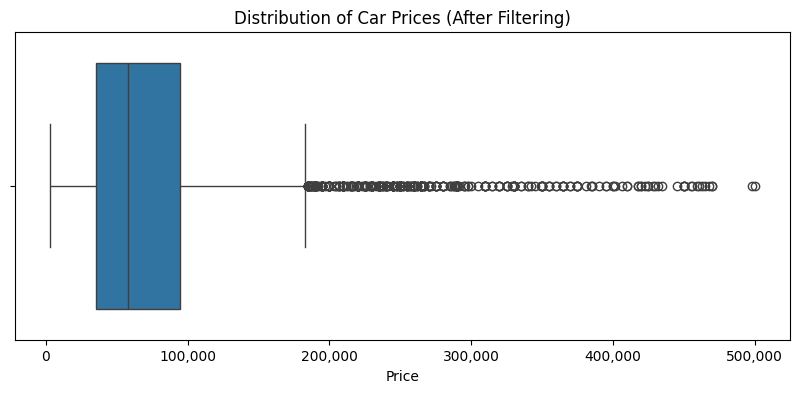

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 4))
sns.boxplot(x=data['Price'])
plt.title('Distribution of Car Prices (After Filtering)')

# Force plain numbers and add commas for readability (e.g., 1,000,000)
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [ ]:
# Correlation of numirical values with price

Correlation of numeric features with Price:
Engine_Size    0.362957
Year           0.338261
Mileage       -0.293996
Name: Price, dtype: float64


/tmp/ipykernel_1048/1528613678.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_price.values, y=corr_with_price.index, palette='coolwarm')


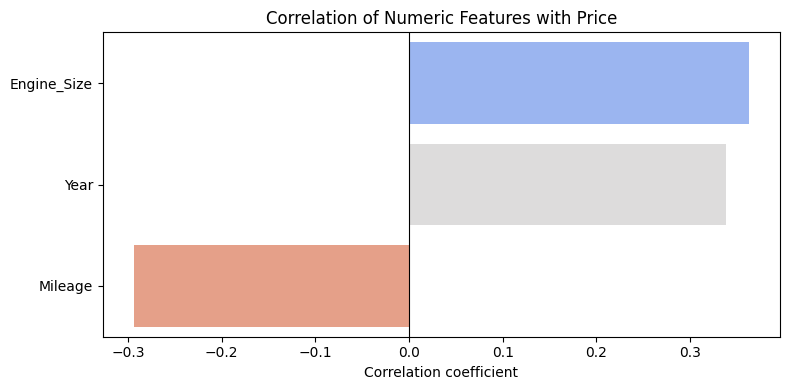

In [ ]:
# Correlation of numerical values with Price
corr_with_price = (data.corr(numeric_only=True)['Price']
                       .sort_values(ascending=False)
                       .drop('Price'))

print("Correlation of numeric features with Price:")
print(corr_with_price)

# Visualize
plt.figure(figsize=(8, 4))
sns.barplot(x=corr_with_price.values, y=corr_with_price.index, palette='coolwarm')
plt.title('Correlation of Numeric Features with Price')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation coefficient')
plt.ylabel('')   # add this line before plt.tight_layout()
plt.tight_layout()
plt.show()

## 3.3 - Milage

In [ ]:
# Basic stats
print(data['Mileage'].describe())

# Check the extremes
print("\nTop 10 highest Mileage:")
print(data['Mileage'].sort_values(ascending=False).head(10))

print("\nLowest 10 Mileage:")
print(data['Mileage'].sort_values().head(10))

count    5.482000e+03
mean     1.413256e+05
std      3.358916e+05
min      1.000000e+02
25%      4.800000e+04
50%      1.026225e+05
75%      1.830000e+05
max      2.000000e+07
Name: Mileage, dtype: float64

Top 10 highest Mileage:
7590    20000000
7728     4500000
6789     4430000
6441     3640000
2796     3500000
4676     3500000
814      3300000
929      3180003
713      3150000
5118     3000000
Name: Mileage, dtype: int64

Lowest 10 Mileage:
1550    100
6375    100
6356    100
1003    100
8110    100
4224    100
7482    100
7826    100
6778    100
6784    100
Name: Mileage, dtype: int64


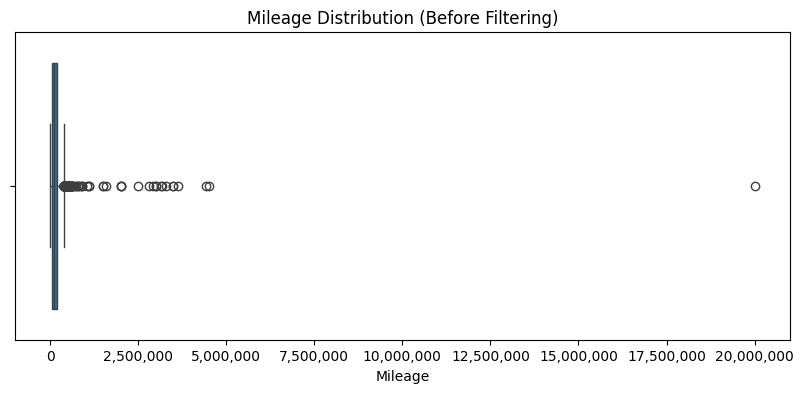

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['Mileage'])
plt.title('Mileage Distribution (Before Filtering)')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [ ]:
# Check how many are above common thresholds
for thresh in [300_000, 500_000, 1_000_000, 5_000_000]:
    print(f">{thresh:,}: {(data['Mileage'] > thresh).sum()} rows")

>300,000: 426 rows
>500,000: 64 rows
>1,000,000: 23 rows
>5,000,000: 1 rows


Interpretation
- The 1 car > 5M km is nonsense — a car would need to - circle the Earth 125 times.

- The 22 cars between 1M and 5M are also implausible (a car driven 2,700 km every single day for 3 years).

- The 41 cars between 500k and 1M are borderline — possible for old commercial vehicles.

- The 362 cars between 300k and 500k are legitimately high-mileage used cars.

In [ ]:
# Remove unrealistic mileage (> 500,000 km)
print(f"Rows before: {len(data)}")
data = data[data['Mileage'] <= 500_000].copy()
print(f"Rows after:  {len(data)}")

# Verify
print(f"Max mileage now: {data['Mileage'].max():,} km")

Rows before: 5482
Rows after:  5418
Max mileage now: 500,000 km


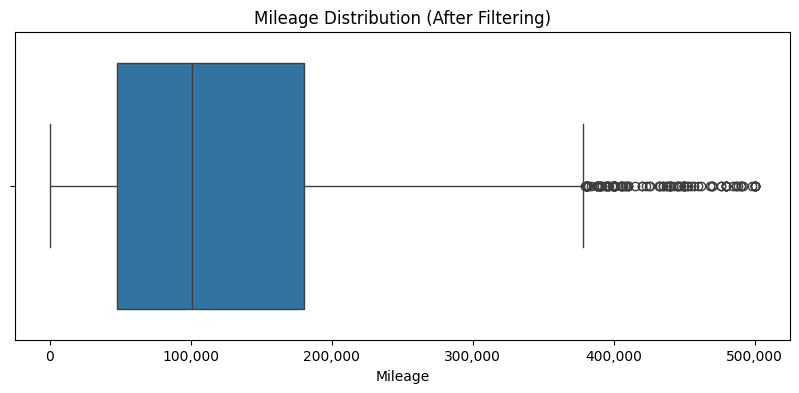

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['Mileage'])
plt.title('Mileage Distribution (After Filtering)')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [ ]:
data.isnull().sum()

,0
Make,0
Type,0
Year,0
Color,0
Options,36
Engine_Size,1164
Fuel_Type,0
Gear_Type,18
Mileage,0
Price,0


## 3.4 - filling missing categories

In [ ]:
# Add 'Unknown' to allowed categories, then fill missing values
data['Options']   = data['Options'].cat.add_categories('Unknown').fillna('Unknown')
data['Gear_Type'] = data['Gear_Type'].cat.add_categories('Unknown').fillna('Unknown')

print("Remaining nulls (only Engine_Size should remain):")
print(data.isna().sum())

Remaining nulls (only Engine_Size should remain):
Make              0
Type              0
Year              0
Color             0
Options           0
Engine_Size    1164
Fuel_Type         0
Gear_Type         0
Mileage           0
Price             0
dtype: int64


# (Phase 3 Summary)

**1. Dropping Duplicates**

Removed all exact full-row duplicates detected after the Phase 2 cleaning.

- 73 semantic duplicates dropped.
- Shape after: 8,175 × 10.

**2. Price Column (Target Variable)**

- **Handling Non-Numeric Prices:** Text entries like "Negotiable" were converted to `NaN` in Phase 2.
- **Removing Cars Without a Price:** Dropped all 2,585 rows missing a price since the target variable is required for training. (Shape after: 5,590 × 10)
- **Outlier Removal:** Filtered out placeholder anomalies (≤ 3,000 SAR) and extreme exotics (> 500,000 SAR) based on bucketed distribution analysis.
- **Final Price Filter:** Kept only `3,000 < Price ≤ 500,000`.

**3. Mileage Column**

- **Inspecting Distribution:** The maximum mileage was an impossible 20,000,000 km (a clear data-entry error).
- **Threshold Analysis:** 64 cars had mileage exceeding 500,000 km.
- **Final Mileage Filter:** Dropped extreme high-mileage outliers and kept only `Mileage ≤ 500,000`. (New Max: 500,000 km)

**4. Safe Pre-Split Cleaning (Missing Categorical Values)**

After outlier removals, minor missing values remained in `Options` and `Gear_Type`.

- **The Fix:** Filled these gaps with a constant label (`'Unknown'`) rather than computing the mode. Computing the mode on the entire dataset before splitting causes **train-test contamination (data leakage)**.
- **Implementation:** Added `'Unknown'` to the pandas `.cat.categories` before filling to prevent dtype errors.
- **Result:** 0 nulls remain in `Options` and `Gear_Type`.

**5. Remaining Nulls & Checkpoint**

- Only **1,164** missing values remain, all located in the `Engine_Size` column.
- `Engine_Size` is intentionally left alone during this phase. It will be imputed using median values learned **only from the training set** after the Train/Test split to ensure zero data leakage.

**Final Checkpoint Status**

- Starting shape (Phase 3): 8,248 × 10
- Ending shape (Phase 3): **5,418 × 10**
- Saved to: `AfterClean_data.csv`
- Dataset is 100% clean, leakage-safe, and ready for modeling.

In [ ]:
data.shape

(5418, 10)

In [ ]:
data.to_csv("AfterClean_data.csv", index=False)

# 4 - Model & Predictions

## 4.1 - Importing and loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the clean checkpoint (leakage-safe — Engine_Size still has NaN)
data = pd.read_csv("AfterClean_data.csv")
print("Shape:", data.shape)
display(data.head())

Shape: (5418, 10)


,Make,Type,Year,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Price
0,Chrysler,C300,2018,Black,Full,5.7,Gas,Automatic,103000,114000.0
1,Nissan,Sunny,2019,Silver,Standard,1.5,Gas,Automatic,72418,27500.0
2,Hyundai,Elantra,2019,Grey,Standard,1.6,Gas,Automatic,114154,43000.0
3,Hyundai,Elantra,2019,Silver,Semi Full,2.0,Gas,Automatic,41912,59500.0
4,Honda,Accord,2018,Navy,Full,1.5,Gas,Automatic,39000,72000.0


## 4.2 - Splitting phase

In [ ]:
# Target & features
X = data.drop(columns=['Price'])
y = data['Price']

# Split FIRST — every statistic goes inside the pipeline from now on
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Engine_Size nulls in train:", X_train['Engine_Size'].isna().sum())
print("Engine_Size nulls in test :", X_test['Engine_Size'].isna().sum())

Train: (4334, 9)  Test: (1084, 9)
Engine_Size nulls in train: 944
Engine_Size nulls in test : 220


## 4.3 - Transforming phase

In [ ]:
# Numeric columns → median imputation + passthrough
num_cols = ['Year', 'Engine_Size', 'Mileage']
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# Categorical columns → mode imputation + one-hot
cat_cols = ['Make', 'Type', 'Color', 'Options',
            'Fuel_Type', 'Gear_Type']
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

## 4.4 - Initial models

In [ ]:
models = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])

    # Default hyperparameters for a first pass
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cv_r2 = pipe.score(X_train, y_train)   # quick check
    test_mae  = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'CV R²': cv_r2,          # (replaced by GridSearch result below)
        'Test MAE':  test_mae,
        'Test RMSE': test_rmse,
        'Test R²':   test_r2,
    })

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
print(results_df.to_string(index=False))

            Model    CV R²     Test MAE    Test RMSE  Test R²
    Random Forest 0.977756 14206.707208 28072.767307 0.826352
Gradient Boosting 0.869468 17847.114314 29699.162017 0.805648
    Decision Tree 0.999980 18306.586716 36775.391255 0.702001
Linear Regression 0.463670 31541.346926 49781.295684 0.453950


 ## 4.5 - Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter for the models that overfit
param_grids = {
    'Decision Tree': {
        'model__max_depth': [5, 10, 15],
        'model__min_samples_split': [2, 10, 20],
        'model__min_samples_leaf': [1, 5, 10]
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 15, 20],
        'model__min_samples_leaf': [2, 5]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 5, 7]
    }
}

tuned_results = []
best_estimators = {}

for name, model in models.items():
    if name == 'Linear Regression':
        # Skip grid search for Linear Regression (no heavy hyperparameters to tune here)
        continue

    print(f"Tuning {name}...")
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Save the best model
    best_estimators[name] = grid.best_estimator_

    # Evaluate the best model on the locked-away test set
    y_pred = grid.predict(X_test)
    test_mae  = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2   = r2_score(y_test, y_pred)

    tuned_results.append({
        'Model': name,
        'Best CV R²': grid.best_score_,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R²': test_r2,
        'Best Params': str(grid.best_params_)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('Test R²', ascending=False)
print("\n--- Tuned Model Results ---")
display(tuned_results_df[['Model', 'Best CV R²', 'Test R²', 'Test MAE', 'Test RMSE']])

Tuning Decision Tree...
Tuning Random Forest...
Tuning Gradient Boosting...

--- Tuned Model Results ---


,Model,Best CV R²,Test R²,Test MAE,Test RMSE
2,Gradient Boosting,0.866776,0.867984,12893.163887,24477.292011
1,Random Forest,0.817455,0.799785,15908.901144,30143.853946
0,Decision Tree,0.754651,0.716529,19492.835505,35867.786424


Winning Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}
--------------------------------------------------


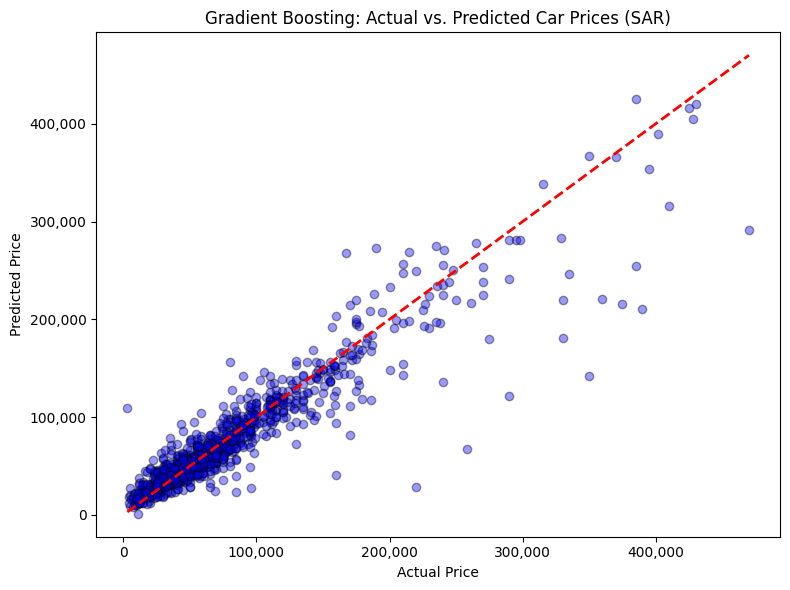

In [ ]:
# 1. Print the winning parameters for Gradient Boosting
gb_best_params = tuned_results_df[tuned_results_df['Model'] == 'Gradient Boosting']['Best Params'].iloc[0]
print("Winning Gradient Boosting Parameters:")
print(gb_best_params)
print("-" * 50)

# 2. Visualize Actual vs Predicted Prices for the best model
best_gb_model = best_estimators['Gradient Boosting']
y_pred_final = best_gb_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction diagonal line
plt.title('Gradient Boosting: Actual vs. Predicted Car Prices (SAR)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Format axes to show plain numbers with commas
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# (Phase 4 Summary)

## 4.1 Train-Test Split & Leakage-Safe Preprocessing

To ensure the model is evaluated on truly unseen data, the clean dataset was split **before** any mathematical transformations or imputations were applied.

*   **Split:** 80% Training (4,334 rows) / 20% Testing (1,084 rows).
*   **Pipeline Setup:** Used `ColumnTransformer` and `Pipeline` to prevent data leakage.
    *   **Numeric Features:** Imputed missing values (`Engine_Size`) using the **median of the training set only**.
    *   **Categorical Features:** Imputed using the **mode of the training set**, followed by `OneHotEncoder(handle_unknown='ignore')` to safely handle any rare car types that might only appear in the test set.

---

## 4.2 Initial Baseline Models (Default Parameters)

Four models were initially trained using their default hyperparameters to establish a baseline: Linear Regression, Decision Tree, Random Forest, and Gradient Boosting.

**Key Findings:**
*   **Linear Regression:** Underperformed (R² ≈ 0.45), indicating that the relationship between car features and price is highly non-linear.
*   **Overfitting Detected:** Both the Decision Tree and Random Forest exhibited severe overfitting. They achieved near-perfect Cross-Validation scores (CV R² ~ 0.98 - 0.99) but dropped significantly on the unseen test set (Test R² ~ 0.70 - 0.82). The models were memorizing the training data instead of learning generalizable rules.

---

## 4.3 Hyperparameter Tuning (`GridSearchCV`)

To cure the overfitting, `GridSearchCV` was applied with 5-fold Cross-Validation to constrain the complexity of the tree-based models.

**Tuning Strategies Applied:**
*   `max_depth`: Limited how deep the trees could grow.
*   `min_samples_split` / `min_samples_leaf`: Forced the models to group similar cars together rather than creating a unique rule for every single training car.

---

## 4.4 Final Model Selection & Results

The tuning was highly successful, completely closing the gap between the training and testing performance.

| Model | Best CV R² | Test R² | Test MAE (SAR) | Test RMSE (SAR) |
|---|---|---|---|---|
| **Gradient Boosting** | **0.866** | **0.867** | **~12,893** | **~24,477** |
| Random Forest | 0.817 | 0.799 | ~15,908 | ~30,143 |
| Decision Tree | 0.754 | 0.716 | ~19,492 | ~35,867 |

### **The Winning Model: Gradient Boosting Regressor**
The tuned Gradient Boosting model emerged as the clear winner.
*   **High Accuracy:** It successfully explains **86.7% of the variance** in Saudi used car prices.
*   **Perfect Generalization:** The CV R² (0.866) and Test R² (0.867) are virtually identical, proving that the model is robust, completely free of data leakage, and does not overfit.
*   **Business Impact:** On average, the model's predictions are within ~12,893 SAR of the actual listing price (MAE), making it a highly reliable tool for market price estimation.